# 02 Feature Engineering

Resample harian → bulanan, uji stasioneritas, ACF/PACF, dan persiapan exogenous untuk SARIMAX. Hasil agregasi bulanan disimpan ke `dataset/monthly_aggregated.csv` agar dapat dipakai langsung di notebook modeling.

---
## Setup & Import Library

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, kpss

plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
})
sns.set_palette('Set2')
PALETTE = sns.color_palette('Set2')


---
## Load Dataset Harian

In [2]:
DATASET_PATH = 'dataset/merged_dataset-1940-2025-bogor.csv'
df = pd.read_csv(DATASET_PATH, parse_dates=['time'])

# normalisasi nama kolom: hapus satuan dalam kurung & ubah '_to_' jadi '_'
df.columns = (df.columns
              .str.replace(r'\s*\(.*\)', '', regex=True)
              .str.replace('_to_', '_'))

# Konstanta kolom
COL_TIME = 'time'
COL_WEATHER_CODE = 'weather_code'
COL_TEMP_2M_MAX = 'temperature_2m_max'
COL_TEMP_2M_MEAN = 'temperature_2m_mean'
COL_TEMP_2M_MIN = 'temperature_2m_min'
COL_APPARENT_TEMP_MEAN = 'apparent_temperature_mean'
COL_SUNSHINE_DURATION = 'sunshine_duration'
COL_CLOUD_COVER_MEAN = 'cloud_cover_mean'
COL_PRECIPITATION_SUM = 'precipitation_sum'
COL_PRECIPITATION_HOURS_SUM = 'precipitation_hours'
COL_RAIN_SUM = 'rain_sum'
COL_SOIL_MOIST_0_7CM_MEAN = 'soil_moisture_0_7cm_mean'
COL_SOIL_TEMP_0_7CM_MEAN = 'soil_temperature_0_7cm_mean'
COL_RELATIVE_HUMIDITY_2M_MEAN = 'relative_humidity_2m_mean'

FULL_COL = [COL_TIME, COL_WEATHER_CODE, COL_TEMP_2M_MAX, COL_TEMP_2M_MEAN, COL_TEMP_2M_MIN,
            COL_APPARENT_TEMP_MEAN, COL_SUNSHINE_DURATION, COL_CLOUD_COVER_MEAN,
            COL_PRECIPITATION_SUM, COL_PRECIPITATION_HOURS_SUM, COL_RAIN_SUM,
            COL_SOIL_MOIST_0_7CM_MEAN, COL_SOIL_TEMP_0_7CM_MEAN, COL_RELATIVE_HUMIDITY_2M_MEAN]

df = df[FULL_COL].set_index('time')
df.index.freq = 'D'
print(f'Dataset dimuat: {df.shape[0]:,} baris × {df.shape[1]} kolom')
print(f'Rentang waktu : {df.index.min().date()} → {df.index.max().date()}')
df.head()


Dataset dimuat: 31,411 baris × 13 kolom
Rentang waktu : 1940-01-02 → 2025-12-31


,weather_code,temperature_2m_max,temperature_2m_mean,temperature_2m_min,apparent_temperature_mean,sunshine_duration,cloud_cover_mean,precipitation_sum,precipitation_hours,rain_sum,soil_moisture_0_7cm_mean,soil_temperature_0_7cm_mean,relative_humidity_2m_mean
time,,,,,,,,,,,,,
1940-01-02,63,27.5,23.6,21.2,28.4,22699.39,100.0,16.0,17.0,16.0,0.501,25.2,94.0
1940-01-03,63,27.9,23.5,21.4,27.5,24942.02,100.0,13.6,17.0,13.6,0.501,25.1,89.0
1940-01-04,55,25.6,23.0,21.2,26.4,2253.88,100.0,8.2,19.0,8.2,0.506,24.1,90.0
1940-01-05,63,29.1,23.8,20.4,27.4,32400.00,93.0,5.5,7.0,5.5,0.492,24.8,85.0
1940-01-06,63,28.6,23.6,20.5,27.9,39454.50,80.0,24.4,14.0,24.4,0.496,25.2,89.0


## 2.1 Target & Exogenous — Resample Bulanan

**Target SARIMAX (4 series):**
- `temperature_2m_mean` → suhu udara rata-rata (mean bulanan)
- `precipitation_sum` → curah hujan (sum bulanan)
- `soil_moisture_0_7cm_mean` → kelembaban tanah (mean bulanan)
- `soil_temperature_0_7cm_mean` → suhu tanah (mean bulanan)

An exogenous variable in SARIMAX is an external, independent time series that influences the target variable but is not caused by it.
**Exogenous (X) candidates:** `relative_humidity_2m_mean`, `sunshine_duration`, `precipitation_hour_sum`,`cloud_cover_mean` 

**Split:**
- Train: 1940-01 → 2015-12  (76 tahun, 912 bulan)
- Test : 2016-01 → 2025-12  (10 tahun, 120 bulan)

Granularitasbulanan dipilih karena: (1) cocok dengan period musiman m=12 untuk SARIMAX, (2) ringan dibanding daily, (3) selaras dengan decomposisi STL pada EDA, (4) horizon bulanan lebih relevan untuk kalender tanam.

In [3]:
# Resample harian -> bulanan
# precipitation_sum pakai SUM (akumulasi); sisanya pakai MEAN

# COL_TIME = 'time' # waktu (tanggal) 0
# COL_WEATHER_CODE = 'weather_code' # kode cuaca (0-99)  1
# COL_TEMP_2M_MAX = 'temperature_2m_max' # suhu maksimum 2 meter (°C) 2
# COL_TEMP_2M_MEAN = 'temperature_2m_mean' # suhu rata-rata 2 meter (°C) 2
# COL_TEMP_2M_MIN = 'temperature_2m_min' # suhu minimum 2 meter (°C) 3
# COL_APPARENT_TEMP_MEAN = 'apparent_temperature_mean' # suhu terasa rata-rata (°C) 3
# COL_SUNSHINE_DURATION = 'sunshine_duration' # durasi sinar matahari (s) 4
# COL_CLOUD_COVER_MEAN = 'cloud_cover_mean' # tutupan awan rata-rata (%) 5
# COL_PRECIPITATION_SUM = 'precipitation_sum' # jumlah presipitasi (mm) 5
# COL_PRECIPITATION_HOURS_SUM = 'precipitation_hours' # jumlah jam presipitasi (jam) 6
# COL_RAIN_SUM = 'rain_sum' # jumlah hujan (mm) 7
# COL_SOIL_MOIST_0_7CM_MEAN = 'soil_moisture_0_7cm_mean' # kelembaban tanah 0-7 cm rata-rata (m³/m³) 8
# COL_SOIL_TEMP_0_7CM_MEAN = 'soil_temperature_0_7cm_mean' # suhu tanah 0-7 cm rata-rata (°C) 9 
# COL_RELATIVE_HUMIDITY_2M_MEAN = 'relative_humidity_2m_mean' # kelembaban relatif 2 meter rata-rata (%) 10

agg_map = {
    COL_TEMP_2M_MEAN: 'mean',
    COL_PRECIPITATION_SUM: 'mean',
    COL_SOIL_MOIST_0_7CM_MEAN: 'mean',
    COL_SOIL_TEMP_0_7CM_MEAN: 'mean',
    COL_RELATIVE_HUMIDITY_2M_MEAN: 'mean',
    COL_SUNSHINE_DURATION: 'mean',
    COL_CLOUD_COVER_MEAN: 'mean',
    COL_PRECIPITATION_HOURS_SUM: 'mean',
}
df_m = df[list(agg_map.keys())].resample('MS').agg(agg_map)
df_m.index.freq = 'MS'

# Definisi target & exogenous
TARGETS = [COL_TEMP_2M_MEAN, COL_PRECIPITATION_SUM,
           COL_SOIL_MOIST_0_7CM_MEAN, COL_SOIL_TEMP_0_7CM_MEAN]
EXOG    = [COL_RELATIVE_HUMIDITY_2M_MEAN, COL_SUNSHINE_DURATION, COL_PRECIPITATION_HOURS_SUM, COL_CLOUD_COVER_MEAN]

TARGET_LABELS = {
    COL_TEMP_2M_MEAN: 'Suhu Udara (°C)',
    COL_PRECIPITATION_SUM: 'Curah Hujan (mm)',
    COL_SOIL_MOIST_0_7CM_MEAN: 'Kelembaban Tanah (m³/m³)',
    COL_SOIL_TEMP_0_7CM_MEAN: 'Suhu Tanah (°C)',
}

# Split train / test
SPLIT_DATE = '2016-01-01'
train = df_m.loc[:'2015-12-31']
test  = df_m.loc[SPLIT_DATE:]

print(f'Periode penuh : {df_m.index.min().date()} → {df_m.index.max().date()}  ({len(df_m)} bulan)')
print(f'Train         : {train.index.min().date()} → {train.index.max().date()}  ({len(train)} bulan)')
print(f'Test          : {test.index.min().date()}  → {test.index.max().date()}  ({len(test)} bulan)')
print(f'Targets   ({len(TARGETS)}) : {TARGETS}')
print(f'Exogenous ({len(EXOG)}) : {EXOG}')
df_m.head()

Periode penuh : 1940-01-01 → 2025-12-01  (1032 bulan)
Train         : 1940-01-01 → 2015-12-01  (912 bulan)
Test          : 2016-01-01  → 2025-12-01  (120 bulan)
Targets   (4) : ['temperature_2m_mean', 'precipitation_sum', 'soil_moisture_0_7cm_mean', 'soil_temperature_0_7cm_mean']
Exogenous (4) : ['relative_humidity_2m_mean', 'sunshine_duration', 'precipitation_hours', 'cloud_cover_mean']


,temperature_2m_mean,precipitation_sum,soil_moisture_0_7cm_mean,soil_temperature_0_7cm_mean,relative_humidity_2m_mean,sunshine_duration,cloud_cover_mean,precipitation_hours
time,,,,,,,,
1940-01-01,23.080000,11.686667,0.492667,24.280000,89.166667,24444.787000,96.366667,14.633333
1940-02-01,23.496552,5.834483,0.487862,24.713793,87.344828,34958.672759,88.896552,10.103448
1940-03-01,24.332258,4.167742,0.451000,25.841935,85.290323,40973.355484,75.709677,6.612903
1940-04-01,24.460000,5.283333,0.443300,26.056667,86.033333,38914.885333,66.866667,9.000000
1940-05-01,23.961290,7.435484,0.485677,25.341935,88.967742,30871.090000,87.935484,10.935484


### Simpan hasil agregasi bulanan ke CSV

File ini akan dipakai notebook **03 Modeling SARIMAX** sehingga tidak perlu lagi load dataset harian.

In [4]:
MONTHLY_CSV_PATH = 'dataset/monthly_aggregated.csv'
df_m.to_csv(MONTHLY_CSV_PATH, index=True)
print(f'Saved monthly aggregated data → {MONTHLY_CSV_PATH}')
print(f'Shape: {df_m.shape}   Range: {df_m.index.min().date()} → {df_m.index.max().date()}')
df_m.head()


Saved monthly aggregated data → dataset/monthly_aggregated.csv
Shape: (1032, 8)   Range: 1940-01-01 → 2025-12-01


,temperature_2m_mean,precipitation_sum,soil_moisture_0_7cm_mean,soil_temperature_0_7cm_mean,relative_humidity_2m_mean,sunshine_duration,cloud_cover_mean,precipitation_hours
time,,,,,,,,
1940-01-01,23.080000,11.686667,0.492667,24.280000,89.166667,24444.787000,96.366667,14.633333
1940-02-01,23.496552,5.834483,0.487862,24.713793,87.344828,34958.672759,88.896552,10.103448
1940-03-01,24.332258,4.167742,0.451000,25.841935,85.290323,40973.355484,75.709677,6.612903
1940-04-01,24.460000,5.283333,0.443300,26.056667,86.033333,38914.885333,66.866667,9.000000
1940-05-01,23.961290,7.435484,0.485677,25.341935,88.967742,30871.090000,87.935484,10.935484


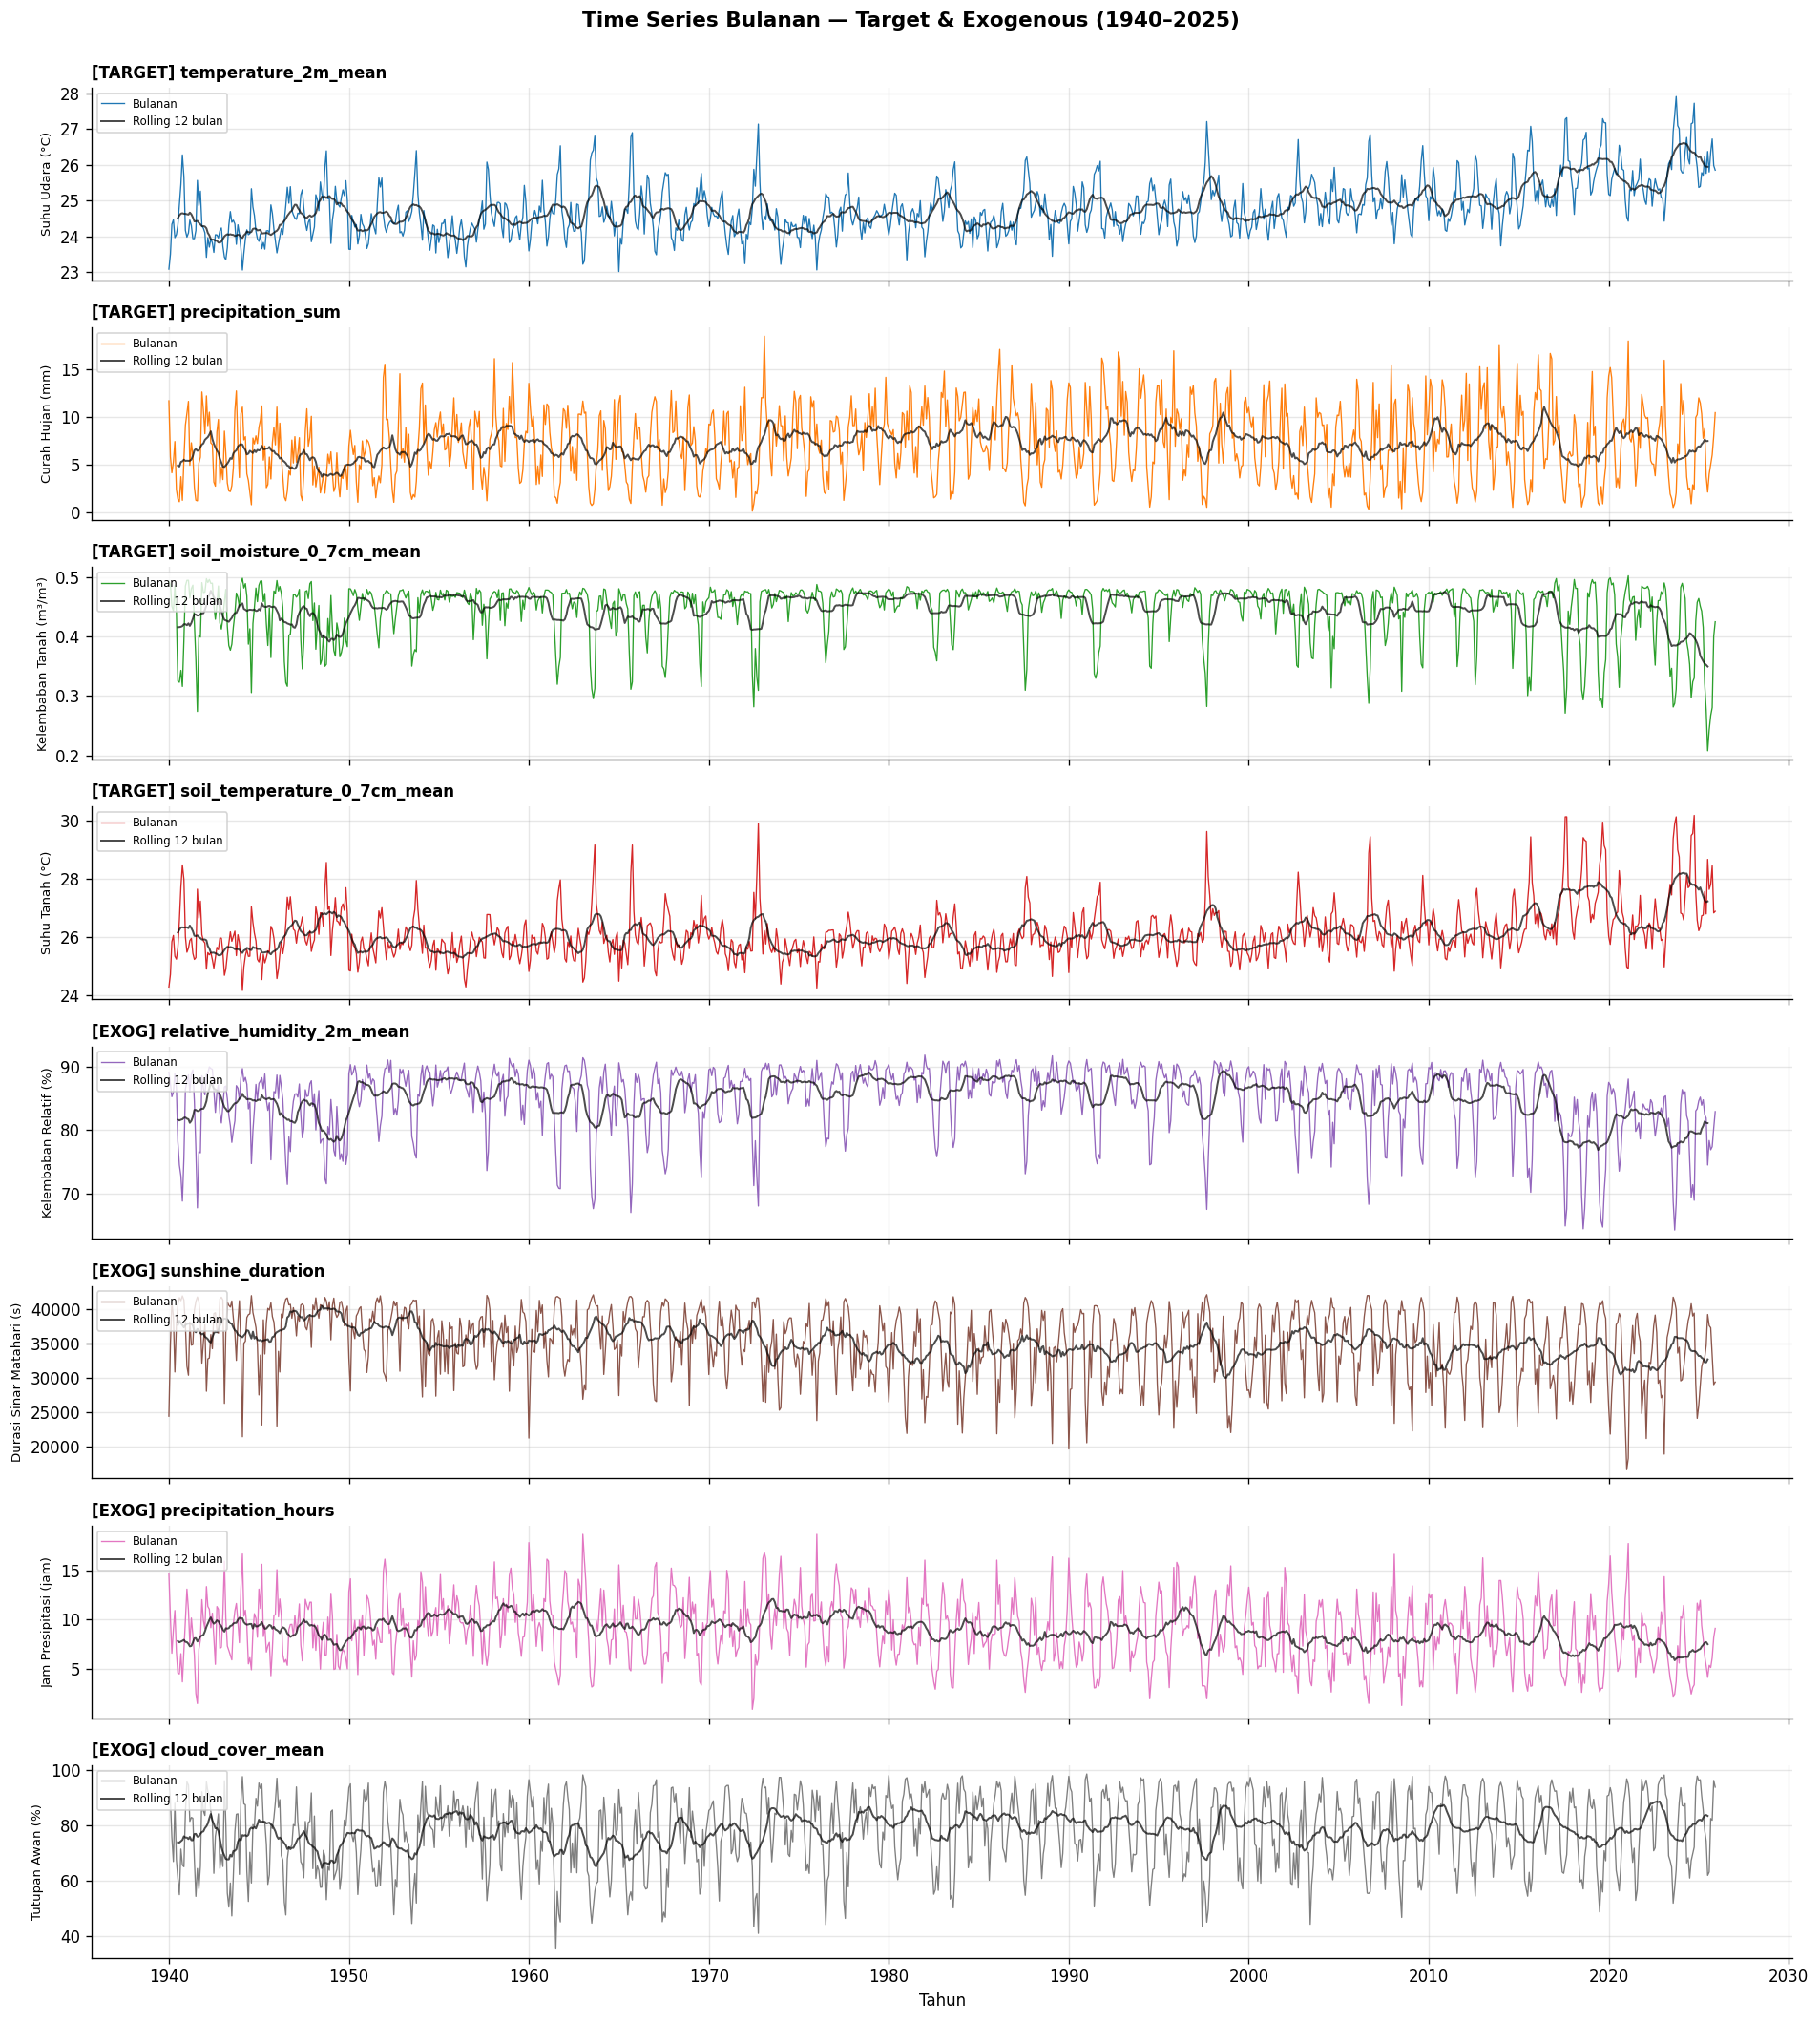

In [5]:
# Visualisasi time series setelah agregasi bulanan (target + exogenous)
VIS_COLS = TARGETS + EXOG
VIS_LABELS = {
    COL_TEMP_2M_MEAN: 'Suhu Udara (°C)',
    COL_PRECIPITATION_SUM: 'Curah Hujan (mm)',
    COL_SOIL_MOIST_0_7CM_MEAN: 'Kelembaban Tanah (m³/m³)',
    COL_SOIL_TEMP_0_7CM_MEAN: 'Suhu Tanah (°C)',
    COL_RELATIVE_HUMIDITY_2M_MEAN: 'Kelembaban Relatif (%)',
    COL_SUNSHINE_DURATION: 'Durasi Sinar Matahari (s)',
    COL_PRECIPITATION_HOURS_SUM: 'Jam Presipitasi (jam)',
    COL_CLOUD_COVER_MEAN: 'Tutupan Awan (%)',
}
vis_colors = sns.color_palette('tab10', n_colors=len(VIS_COLS))

fig, axes = plt.subplots(len(VIS_COLS), 1, figsize=(16, 2.2 * len(VIS_COLS)), sharex=True)
for ax, col, c in zip(axes, VIS_COLS, vis_colors):
    ax.plot(df_m.index, df_m[col], color=c, lw=0.8, label='Bulanan')
    ax.plot(df_m[col].rolling(12, center=True).mean(),
            color='black', lw=1.2, alpha=0.7, label='Rolling 12 bulan')
    tag = '[TARGET]' if col in TARGETS else '[EXOG]'
    ax.set_title(f'{tag} {col}', fontsize=10, fontweight='bold', loc='left')
    ax.set_ylabel(VIS_LABELS.get(col, col), fontsize=8)
    ax.legend(loc='upper left', fontsize=7)
    ax.grid(alpha=0.3)
axes[-1].set_xlabel('Tahun')
plt.suptitle('Time Series Bulanan — Target & Exogenous (1940–2025)',
             fontsize=13, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

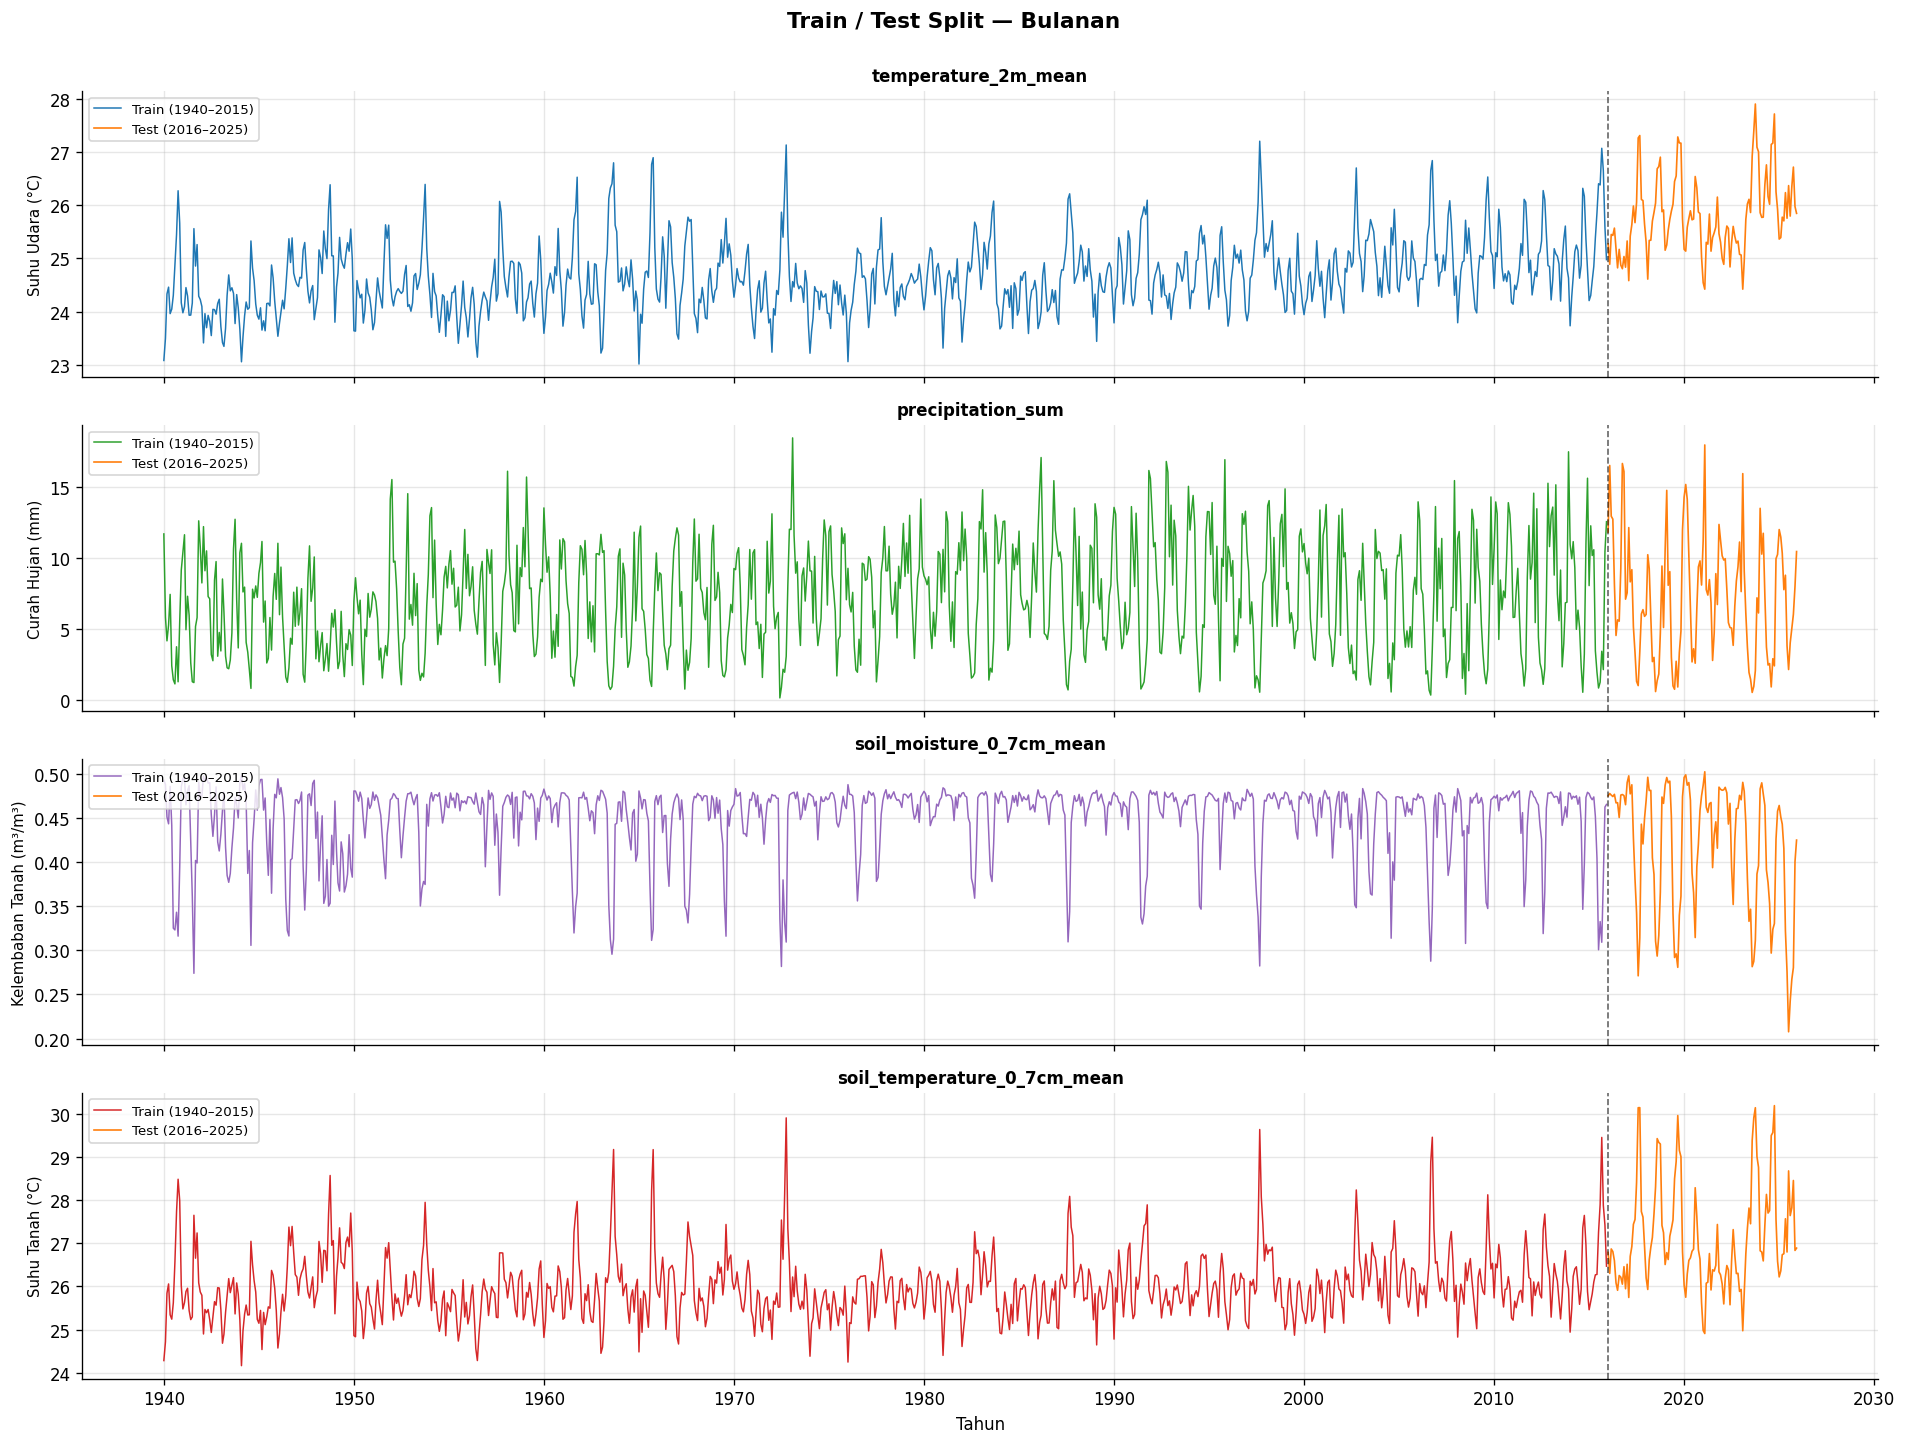

In [6]:
# Visualisasi split train vs test pada 4 target
fig, axes = plt.subplots(4, 1, figsize=(16, 12), sharex=True)
colors = ['#1f77b4', '#2ca02c', '#9467bd', '#d62728']

for ax, col, c in zip(axes, TARGETS, colors):
    ax.plot(train.index, train[col], color=c, lw=0.9, label='Train (1940–2015)')
    ax.plot(test.index,  test[col],  color='#ff7f0e', lw=1.0, label='Test (2016–2025)')
    ax.axvline(pd.Timestamp(SPLIT_DATE), color='black', lw=1, linestyle='--', alpha=0.6)
    ax.set_ylabel(TARGET_LABELS[col], fontsize=9)
    ax.set_title(col, fontsize=10, fontweight='bold')
    ax.legend(loc='upper left', fontsize=8)
    ax.grid(alpha=0.3)

axes[-1].set_xlabel('Tahun')
plt.suptitle('Train / Test Split — Bulanan', fontsize=13, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

## 2.2 Uji Stasioneritas (ADF + KPSS)

| ADF (H0: non-stasioner) | KPSS (H0: stasioner) | Kesimpulan |
|---|---|---|
| reject (p<0.05) | tidak reject (p≥0.05) | **Stasioner** |
| tidak reject | reject | **Non-stasioner** → differencing |
| reject | reject | Stasioner-trend → seasonal/regular diff |
| tidak reject | tidak reject | Tidak konklusif (sampel kurang) |

Diuji pada **train** (1940–2015)

In [7]:
def stationarity_test(series, name=''):
    s = series.dropna()
    adf_stat, adf_p, *_ = adfuller(s, autolag='AIC')
    kpss_stat, kpss_p, *_ = kpss(s, regression='c', nlags='auto')

    adf_stationary  = adf_p  < 0.05   # tolak H0 non-stasioner
    kpss_stationary = kpss_p >= 0.05  # tidak tolak H0 stasioner

    if adf_stationary and kpss_stationary:
        verdict = '✅ Stasioner'
    elif (not adf_stationary) and (not kpss_stationary):
        verdict = '❌ Non-stasioner (diff dibutuhkan)'
    elif adf_stationary and not kpss_stationary:
        verdict = '⚠️  Difference-stasioner (perlu diff)'
    else:
        verdict = '⚠️  Trend-stasioner'

    return {
        'Series'   : name,
        'ADF stat' : round(adf_stat, 3),
        'ADF p'    : round(adf_p, 4),
        'KPSS stat': round(kpss_stat, 3),
        'KPSS p'   : round(kpss_p, 4),
        'Verdict'  : verdict,
    }

# Tes pada level (raw) untuk 4 target
rows_raw = [stationarity_test(train[c], name=c) for c in TARGETS]
stat_raw = pd.DataFrame(rows_raw)
print('=== Stasioneritas — LEVEL (raw) ===')
display(stat_raw.style.set_properties(**{'text-align': 'left'}))

=== Stasioneritas — LEVEL (raw) ===


/tmp/ipykernel_33805/1766286078.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(s, regression='c', nlags='auto')
/tmp/ipykernel_33805/1766286078.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(s, regression='c', nlags='auto')


,Series,ADF stat,ADF p,KPSS stat,KPSS p,Verdict
0,temperature_2m_mean,-3.963000,0.001600,2.080000,0.010000,⚠️ Difference-stasioner (perlu diff)
1,precipitation_sum,-4.757000,0.000100,1.111000,0.010000,⚠️ Difference-stasioner (perlu diff)
2,soil_moisture_0_7cm_mean,-5.719000,0.000000,0.452000,0.054900,✅ Stasioner
3,soil_temperature_0_7cm_mean,-5.384000,0.000000,0.669000,0.016400,⚠️ Difference-stasioner (perlu diff)


In [8]:
# Seasonal differencing (lag 12) + 1st-order differencing
diff_results = {}
for col in TARGETS:
    s = train[col]
    s_d1  = s.diff().dropna()                 # regular diff d=1
    s_D1  = s.diff(12).dropna()               # seasonal diff D=1, m=12
    s_d1D1 = s.diff(12).diff().dropna()       # gabungan d=1, D=1
    diff_results[col] = {
        'd=1'      : s_d1,
        'D=1 (m12)': s_D1,
        'd=1,D=1'  : s_d1D1,
    }

rows_diff = []
for col, variants in diff_results.items():
    for label, series in variants.items():
        rec = stationarity_test(series, name=f'{col}  [{label}]')
        rows_diff.append(rec)

stat_diff = pd.DataFrame(rows_diff)
print('=== Stasioneritas — Setelah Differencing ===')
display(stat_diff.style.set_properties(**{'text-align': 'left'}))

/tmp/ipykernel_33805/1766286078.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(s, regression='c', nlags='auto')
/tmp/ipykernel_33805/1766286078.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(s, regression='c', nlags='auto')
/tmp/ipykernel_33805/1766286078.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(s, regression='c', nlags='auto')
/tmp/ipykernel_33805/1766286078.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value

=== Stasioneritas — Setelah Differencing ===


/tmp/ipykernel_33805/1766286078.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(s, regression='c', nlags='auto')
/tmp/ipykernel_33805/1766286078.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(s, regression='c', nlags='auto')
/tmp/ipykernel_33805/1766286078.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(s, regression='c', nlags='auto')
/tmp/ipykernel_33805/1766286078.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value

,Series,ADF stat,ADF p,KPSS stat,KPSS p,Verdict
0,temperature_2m_mean [d=1],-12.618000,0.000000,0.115000,0.100000,✅ Stasioner
1,temperature_2m_mean [D=1 (m12)],-10.352000,0.000000,0.021000,0.100000,✅ Stasioner
2,"temperature_2m_mean [d=1,D=1]",-9.580000,0.000000,0.015000,0.100000,✅ Stasioner
3,precipitation_sum [d=1],-13.242000,0.000000,0.019000,0.100000,✅ Stasioner
4,precipitation_sum [D=1 (m12)],-11.611000,0.000000,0.024000,0.100000,✅ Stasioner
5,"precipitation_sum [d=1,D=1]",-12.417000,0.000000,0.045000,0.100000,✅ Stasioner
6,soil_moisture_0_7cm_mean [d=1],-12.753000,0.000000,0.027000,0.100000,✅ Stasioner
7,soil_moisture_0_7cm_mean [D=1 (m12)],-8.764000,0.000000,0.038000,0.100000,✅ Stasioner
8,"soil_moisture_0_7cm_mean [d=1,D=1]",-9.636000,0.000000,0.032000,0.100000,✅ Stasioner
9,soil_temperature_0_7cm_mean [d=1],-12.616000,0.000000,0.064000,0.100000,✅ Stasioner


## 2.3 ACF & PACF — Identifikasi Order (p, q, P, Q)

- **PACF cut-off di lag k** → kandidat order **AR(p=k)**.
- **ACF cut-off di lag k** → kandidat order **MA(q=k)**.
- **Spike di lag musiman (12, 24, …)** → komponen seasonal **P/Q**.

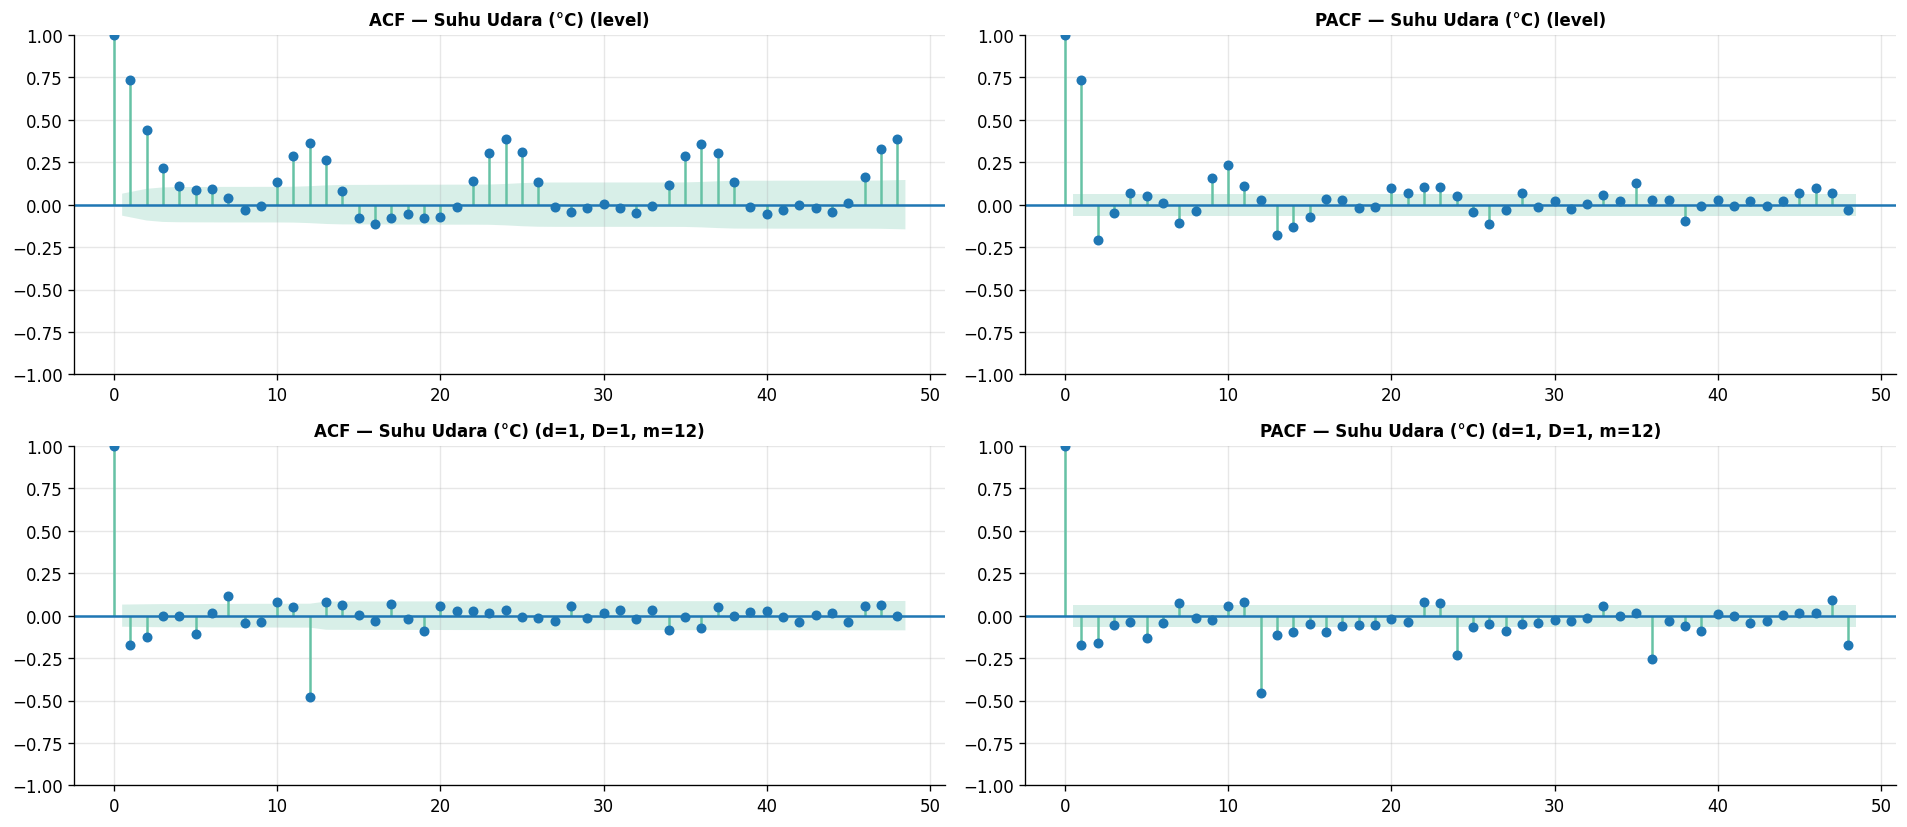

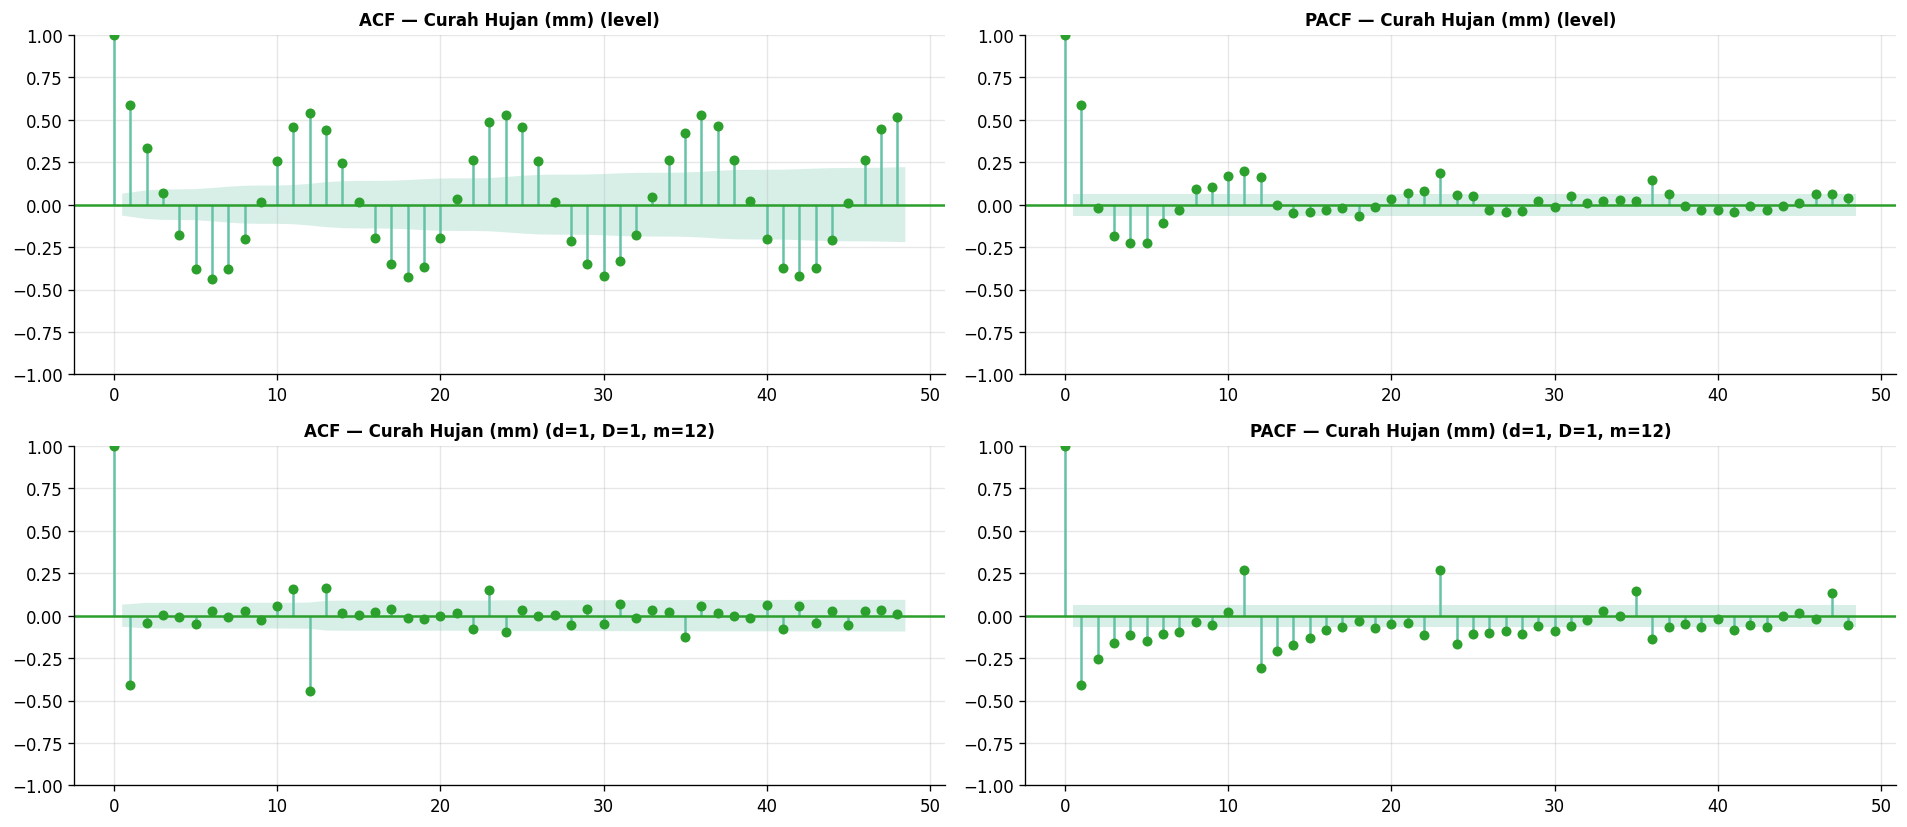

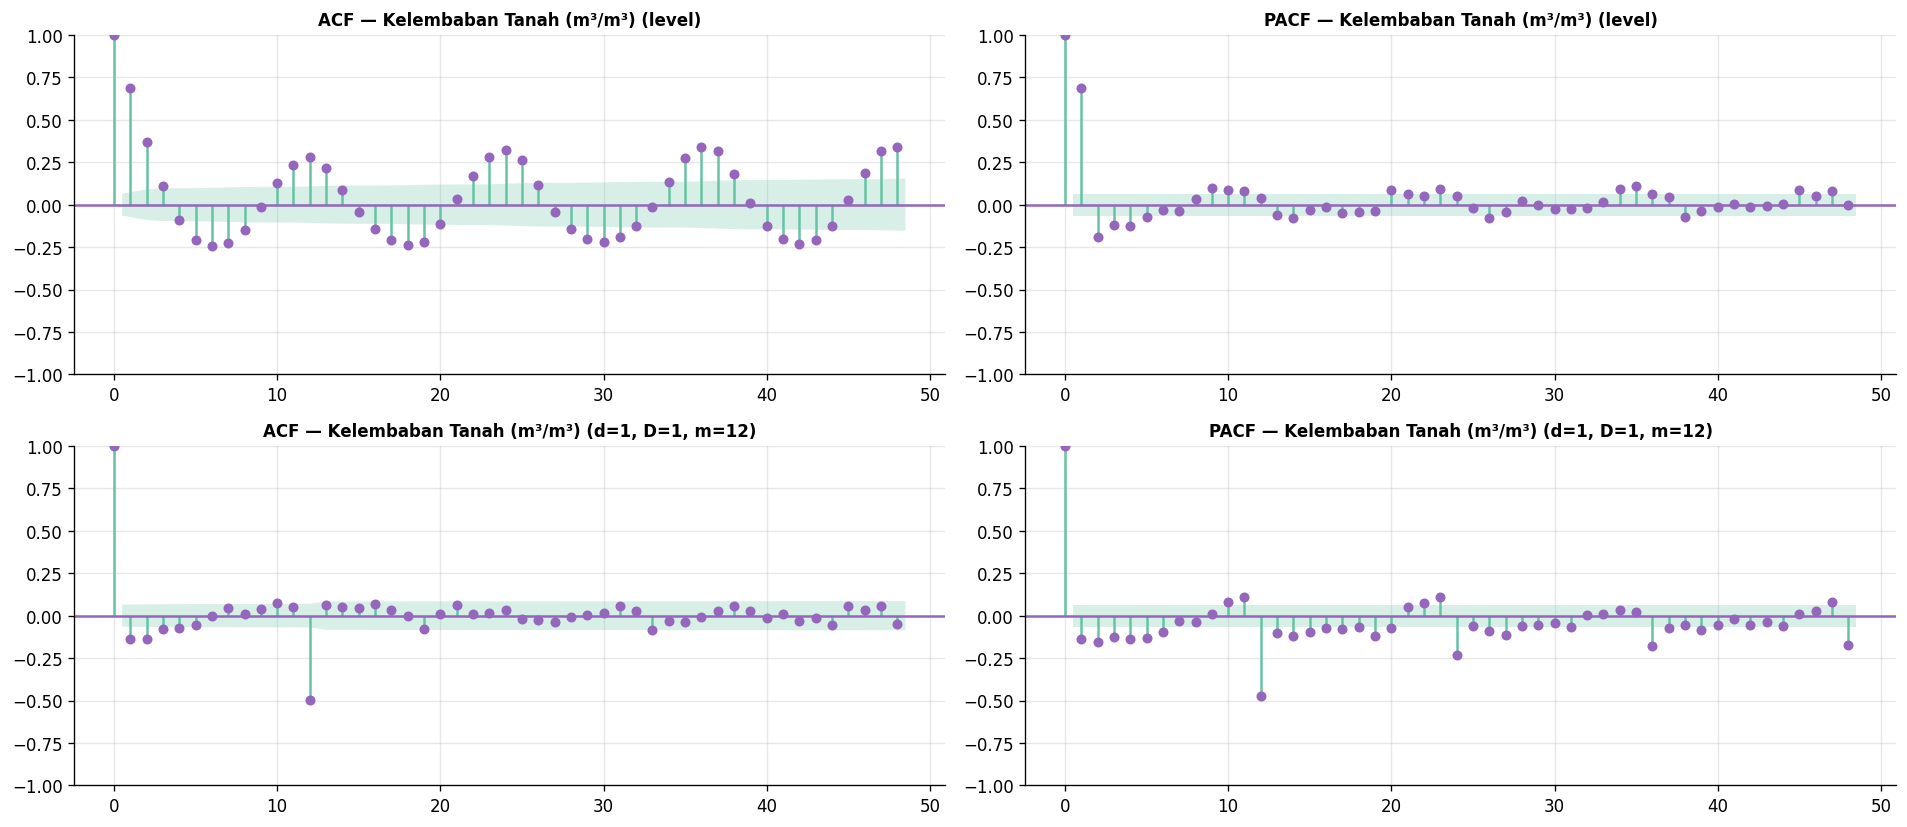

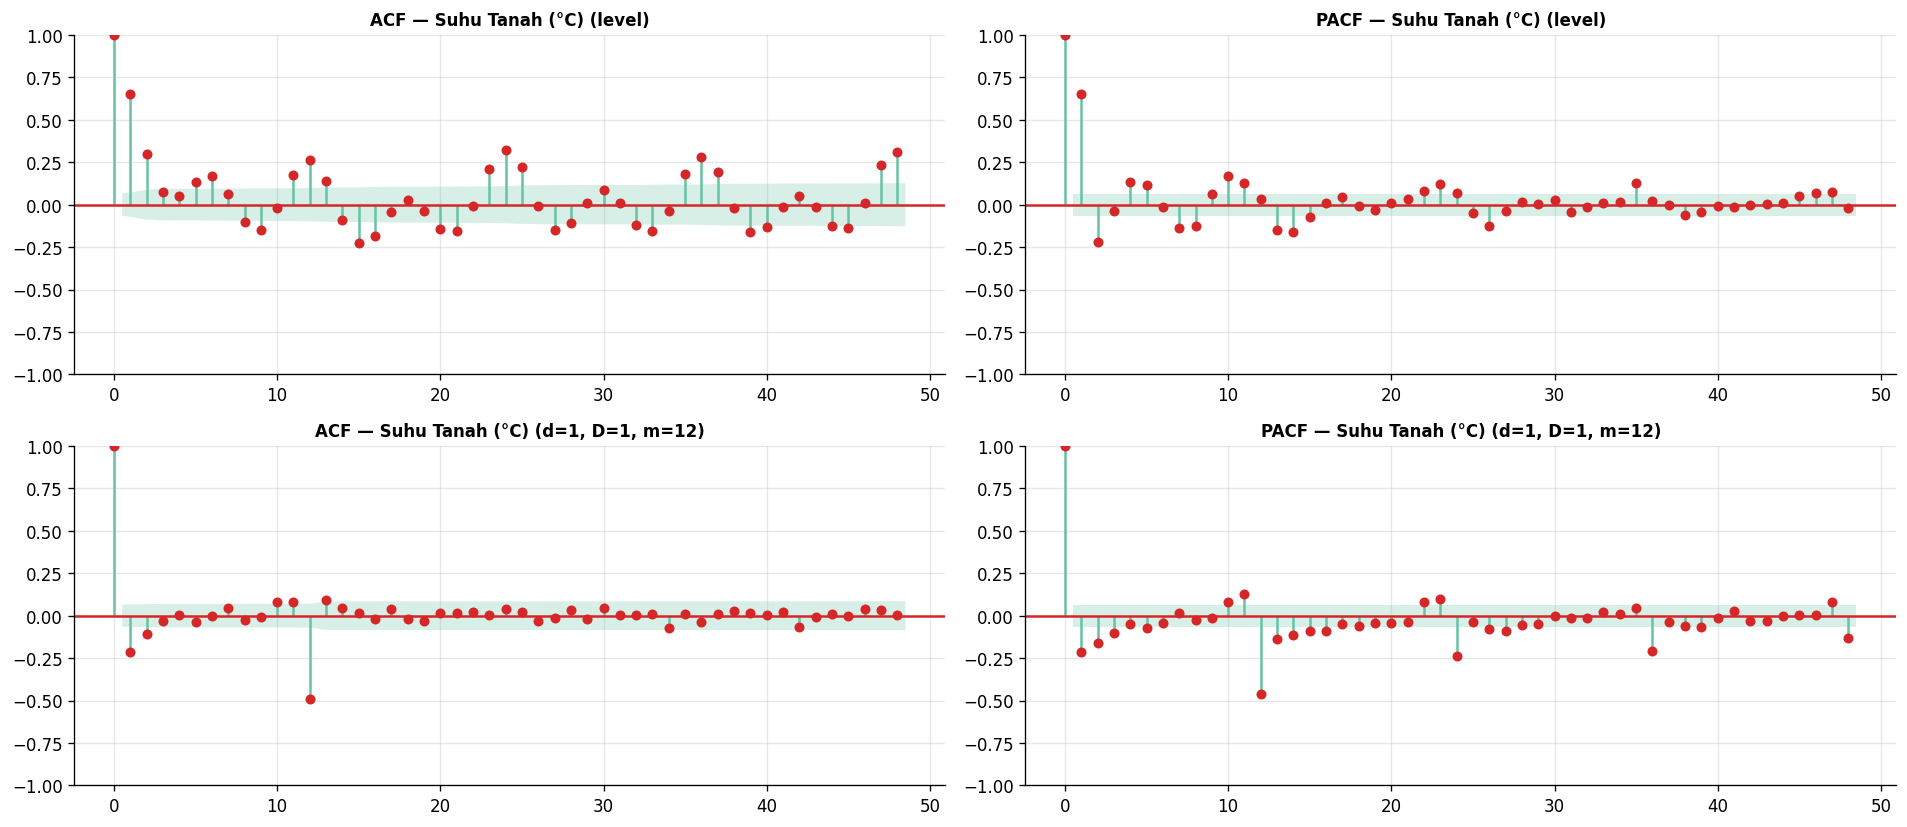

In [9]:
# Plot ACF / PACF: level vs differenced (d=1,D=1) — pakai m=12, lags=48 (4 tahun)
LAGS = 48

def plot_acf_pacf(series_level, series_diff, title, color):
    fig, axes = plt.subplots(2, 2, figsize=(16, 7))

    # Level
    plot_acf(series_level.dropna(),  lags=LAGS, ax=axes[0, 0], color=color)
    axes[0, 0].set_title(f'ACF — {title} (level)',  fontsize=10, fontweight='bold')
    plot_pacf(series_level.dropna(), lags=LAGS, ax=axes[0, 1], color=color, method='ywm')
    axes[0, 1].set_title(f'PACF — {title} (level)', fontsize=10, fontweight='bold')

    # Differenced
    plot_acf(series_diff.dropna(),   lags=LAGS, ax=axes[1, 0], color=color)
    axes[1, 0].set_title(f'ACF — {title} (d=1, D=1, m=12)',  fontsize=10, fontweight='bold')
    plot_pacf(series_diff.dropna(),  lags=LAGS, ax=axes[1, 1], color=color, method='ywm')
    axes[1, 1].set_title(f'PACF — {title} (d=1, D=1, m=12)', fontsize=10, fontweight='bold')

    for ax in axes.flat:
        ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

target_colors = dict(zip(TARGETS, ['#1f77b4', '#2ca02c', '#9467bd', '#d62728']))

for col in TARGETS:
    s_level = train[col]
    s_diff  = diff_results[col]['d=1,D=1']
    plot_acf_pacf(s_level, s_diff, title=TARGET_LABELS[col], color=target_colors[col])

## 2.4 Visualisasi Series Setelah Differencing


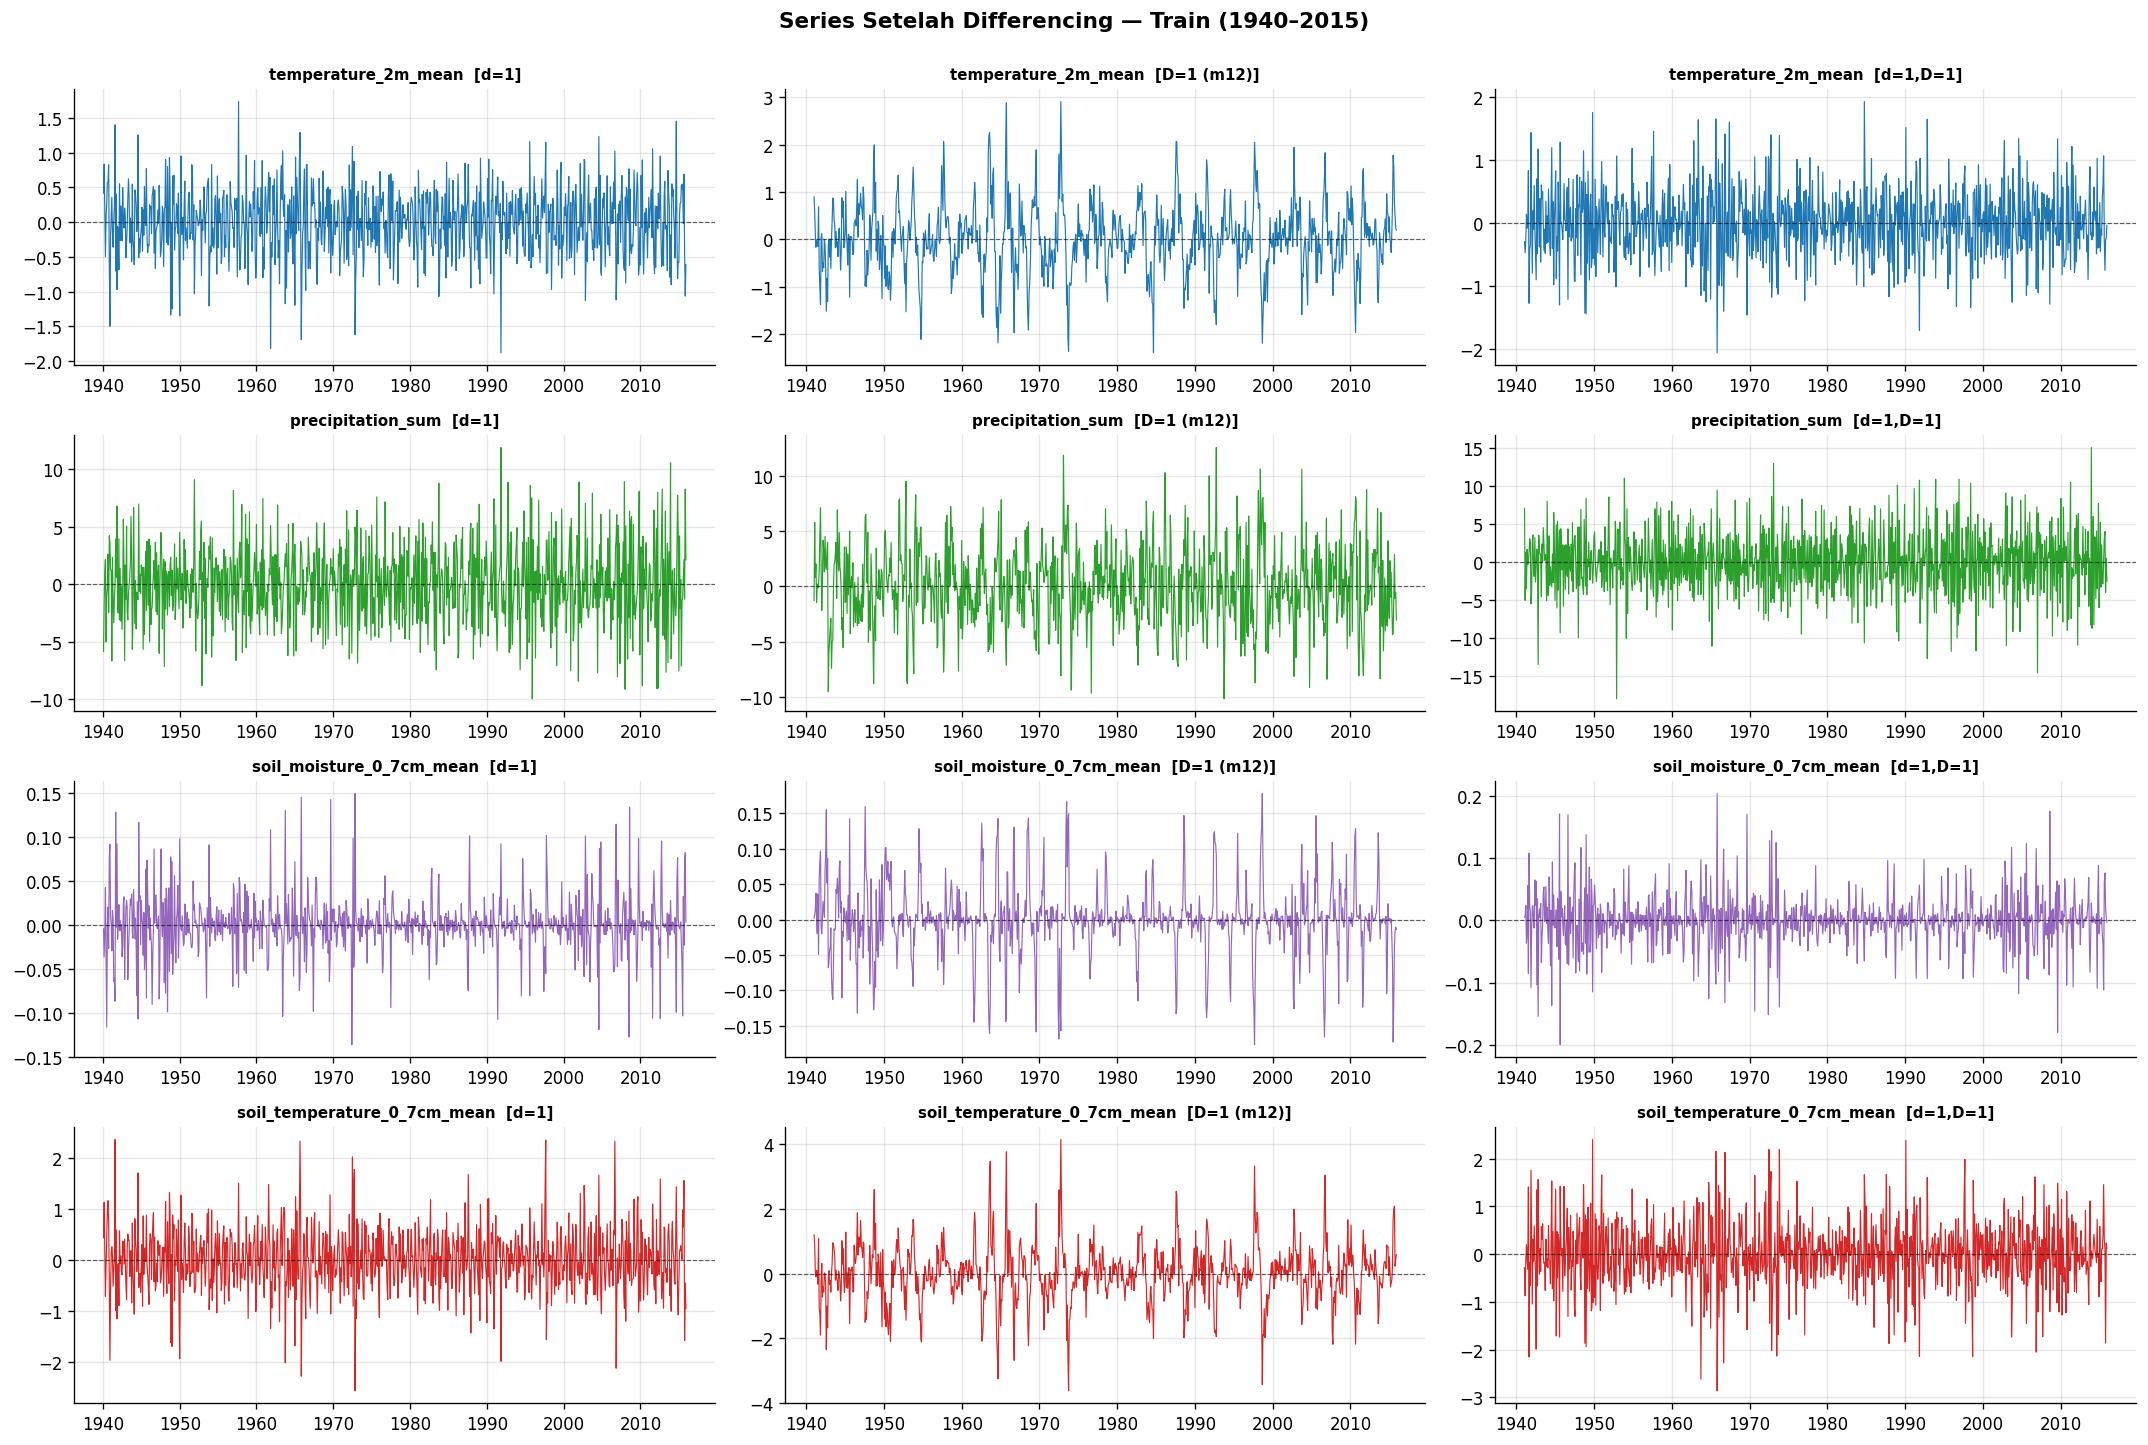

In [10]:
# Plot 3 varian differencing per target
fig, axes = plt.subplots(len(TARGETS), 3, figsize=(18, 12), sharex=False)

for i, col in enumerate(TARGETS):
    c = target_colors[col]
    for j, (label, s) in enumerate(diff_results[col].items()):
        ax = axes[i, j]
        ax.plot(s.index, s.values, color=c, lw=0.7)
        ax.axhline(0, color='black', lw=0.7, linestyle='--', alpha=0.6)
        ax.set_title(f'{col}  [{label}]', fontsize=9, fontweight='bold')
        ax.grid(alpha=0.3)

plt.suptitle('Series Setelah Differencing — Train (1940–2015)',
             fontsize=13, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

## 2.5 Exogenous (X) untuk SARIMAX

In [11]:
# Uji stasioneritas exogenous (di train)
rows_exog = [stationarity_test(train[c], name=c) for c in EXOG]
display(pd.DataFrame(rows_exog).style.set_properties(**{'text-align': 'left'}))

exog_mean = train[EXOG].mean()
exog_std  = train[EXOG].std()

exog_train = (train[EXOG] - exog_mean) / exog_std
exog_test  = (test[EXOG]  - exog_mean) / exog_std

# Korelasi exog vs target (level) pada train
print('\nKorelasi Pearson exog vs target (train):')
display(train[TARGETS + EXOG].corr().loc[EXOG, TARGETS].round(3)
        .style.background_gradient(cmap='RdBu_r', vmin=-1, vmax=1).format('{:.2f}'))

print(f'\nexog_train shape: {exog_train.shape}   exog_test shape: {exog_test.shape}')
exog_train.head()

/tmp/ipykernel_33805/1766286078.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(s, regression='c', nlags='auto')
/tmp/ipykernel_33805/1766286078.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(s, regression='c', nlags='auto')


,Series,ADF stat,ADF p,KPSS stat,KPSS p,Verdict
0,relative_humidity_2m_mean,-4.925000,0.000000,0.640000,0.019000,⚠️ Difference-stasioner (perlu diff)
1,sunshine_duration,-4.306000,0.000400,2.724000,0.010000,⚠️ Difference-stasioner (perlu diff)
2,precipitation_hours,-4.566000,0.000100,1.436000,0.010000,⚠️ Difference-stasioner (perlu diff)
3,cloud_cover_mean,-5.012000,0.000000,0.657000,0.017500,⚠️ Difference-stasioner (perlu diff)



Korelasi Pearson exog vs target (train):


,temperature_2m_mean,precipitation_sum,soil_moisture_0_7cm_mean,soil_temperature_0_7cm_mean
relative_humidity_2m_mean,-0.73,0.73,0.94,-0.65
sunshine_duration,0.56,-0.79,-0.62,0.49
precipitation_hours,-0.64,0.84,0.69,-0.45
cloud_cover_mean,-0.58,0.83,0.74,-0.42



exog_train shape: (912, 4)   exog_test shape: (120, 4)


,relative_humidity_2m_mean,sunshine_duration,precipitation_hours,cloud_cover_mean
time,,,,
1940-01-01,0.719151,-2.256416,1.733082,1.381509
1940-02-01,0.348440,-0.089340,0.309689,0.825406
1940-03-01,-0.069614,1.150380,-0.787120,-0.156274
1940-04-01,0.081575,0.726097,-0.037039,-0.814581
1940-05-01,0.678673,-0.931855,0.571134,0.753861
